In [26]:
# Import the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)

# Load the feature engineered Data for France 2024

In [2]:
df_2024 = pd.read_csv("../data/processed/EU/2024_FR_cleaned.csv")
display(df_2024.head())

,Vehicle,Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,Equipment_Mass,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1807.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,3,132.0,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1757.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,1,125.0,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1787.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,1,156.0,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1791.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,160.0,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1799.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,1,124.0,0,1,0,0,0,0


# Let's see the distributions of the numeric columns:

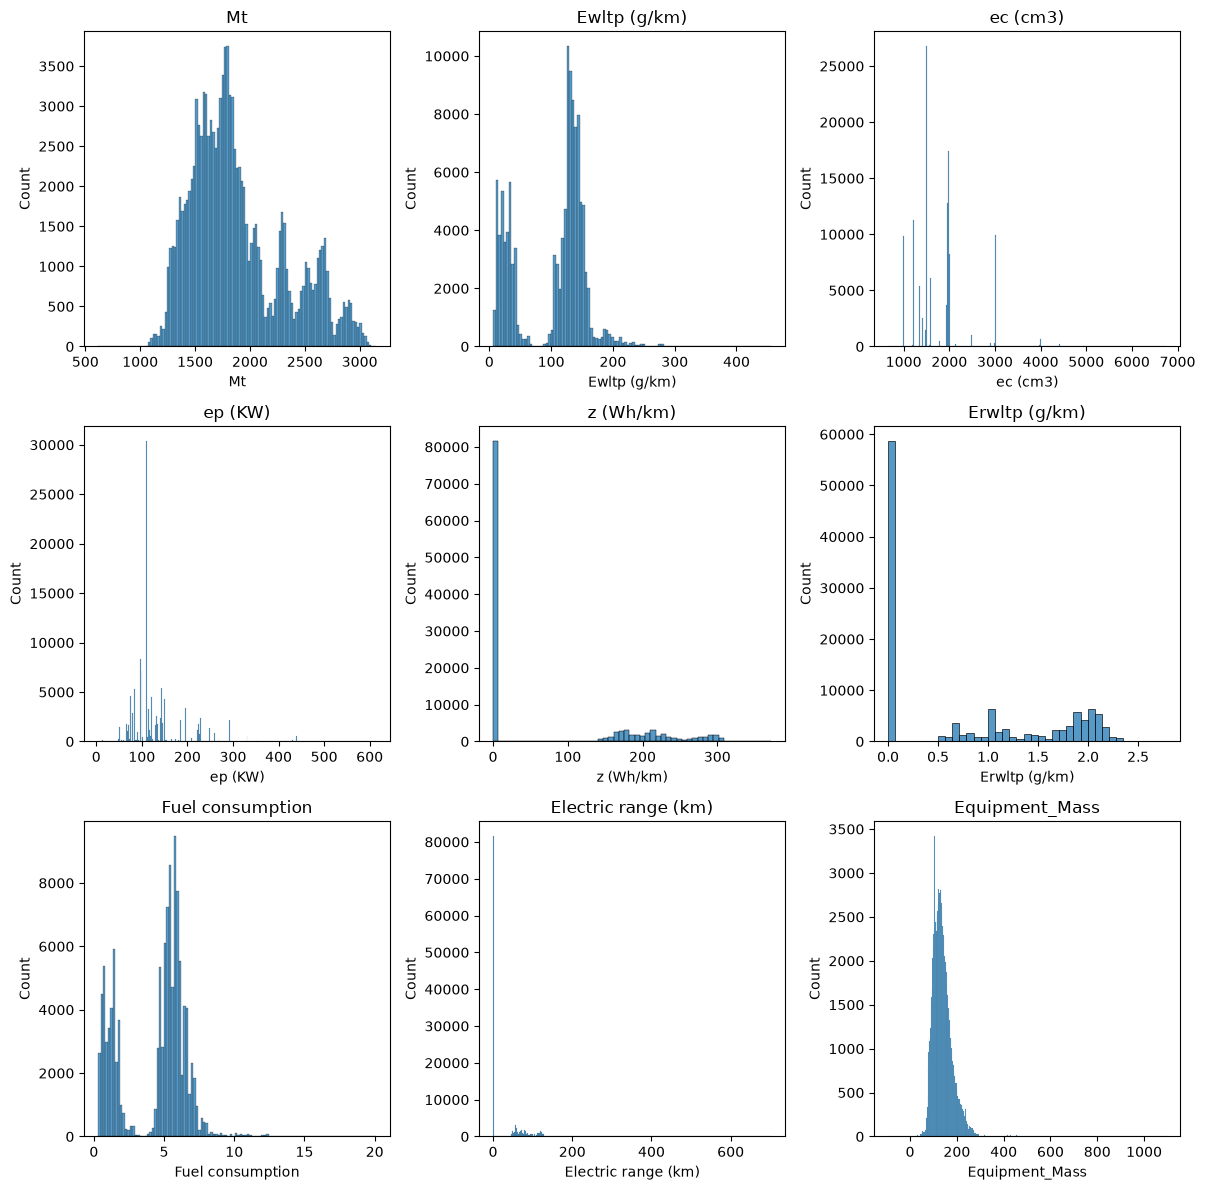

In [3]:
num_cols = [
    "Mt", "Ewltp (g/km)", "ec (cm3)", "ep (KW)", "z (Wh/km)", "Erwltp (g/km)",
    "Fuel consumption", "Electric range (km)", "Equipment_Mass"]
# let's omit "r" for now.

fig = plt.figure(figsize = (12, 12))

for idx, col in enumerate(num_cols, start=1):
    ax = fig.add_subplot(3, 3, idx)  # 3x3 grid, idx. cell
    sns.histplot(x=df_2024[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# We need to evaluate this based on Fuel types:
# Let's remember the Ft and Fm distributions 

In [4]:
print("Ft: Fuel type distribution")
print(df_2024["Ft"].value_counts()/len(df_2024)*100)
print("\n*************\n")
print("Fm: Fuel mode distribution")
print(df_2024["Fm"].value_counts()/len(df_2024)*100)

Ft: Fuel type distribution
Ft
petrol             43.726755
petrol/electric    29.221813
diesel             23.289496
diesel/electric     2.498744
e85                 0.676830
lpg                 0.586363
Name: count, dtype: float64

*************

Fm: Fuel mode distribution
Fm
M    41.805998
P    31.720556
H    25.866979
B     0.586363
F     0.020104
Name: count, dtype: float64


In [5]:
def summary():
    
    my_cols = [
        "z (Wh/km)",
        "Erwltp (g/km)",
        "Fuel consumption",
        "Electric range (km)",
        "r",
        "Equipment_Mass"
    ]
    
    preprocessing_summary = pd.DataFrame({
        "dtype": df_2024[my_cols].dtypes.astype(str),
        "missing_count": df_2024[my_cols].isna().sum(),
        "missing_pct": (df_2024[my_cols].isna().mean() * 100).round(2),
        "zero_count": (df_2024[my_cols] == 0).sum(),
        "zero_pct": ((df_2024[my_cols] == 0).mean() * 100).round(2),
        "unique_values": df_2024[my_cols].nunique(),
        "min": df_2024[my_cols].min(),
        "q1": df_2024[my_cols].quantile(0.25),
        "median": df_2024[my_cols].median(),
        "q3": df_2024[my_cols].quantile(0.75),
        "max": df_2024[my_cols].max()
    }).round(2)
    
    display(preprocessing_summary)

summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
z (Wh/km),float64,0,0.0,81512,68.28,207,0.0,0.0,0.00,174.00,372.00
Erwltp (g/km),float64,0,0.0,58621,49.10,184,0.0,0.0,0.58,1.77,2.78
Fuel consumption,float64,0,0.0,0,0.00,154,0.3,1.6,5.20,5.90,20.10
Electric range (km),float64,0,0.0,81512,68.28,123,0.0,0.0,0.00,58.00,702.00
r,int64,0,0.0,0,0.00,835,1.0,1.0,1.00,3.00,7708.00
Equipment_Mass,float64,0,0.0,0,0.00,529,-94.0,109.0,132.00,159.00,1094.00


We seem to have negative values in the Equipment_Mass column. 
This is suspicious, because we'd expect Mt (test mass) to be greater than the mass of the naked vehicle M (kg). 
Negative equipment mass is impossible.
Let's see how these lines look:

In [6]:
df_2024.loc[df_2024["Equipment_Mass"] < 0].sort_values("Equipment_Mass")

,Vehicle,Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,Equipment_Mass,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
3717,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1AA0M1ISO - 5N - E1*2001/116*0450*70,1644.0,150.0,diesel,M,1968.0,110.0,0.0,1.00,5.7,0.0,1,-94.0,0,1,0,0,0,0
3720,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1AANM1ISO - 5N - E1*2001/116*0450*70,1651.0,150.0,diesel,M,1968.0,110.0,0.0,1.66,5.7,0.0,1,-87.0,0,1,0,0,1,0
3534,VOLKSWAGEN - TIGUAN - ACDTSBX0 - FD7FD7GC009L7N5NVR24BI1ASANM1ISO - 5N - E1*2001/116*0450*69,1667.0,149.0,diesel,M,1968.0,110.0,0.0,1.66,5.7,0.0,1,-72.0,0,1,0,0,1,0
62921,VOLKSWAGEN - T-ROC - DLAAX0AE2 - FM6FM6AJ0254BI1CANNI2GA0 - A1 - E13*2007/46*1845*28,1439.0,151.0,petrol,M,999.0,81.0,0.0,1.17,6.6,0.0,1,-57.0,0,1,0,0,0,0
12722,AUDI - A6 AVANT 55 TFSI E - ADRYAQ1 - QD7AD7DK001101B19S54BIBEM9H66FSB3 - F2 - E1*2007/46*1801*41,2104.0,33.0,petrol/electric,P,1984.0,195.0,204.0,0.00,1.4,65.0,1,-46.0,0,0,0,0,0,1
13401,AUDI - A6 AVANT 50 TFSI E - ADRYAQ1 - QD7AD7DK001091B18S54WEBEM8H66FSB3 - F2 - E1*2007/46*1801*45,2104.0,34.0,petrol/electric,P,1984.0,195.0,206.0,0.00,1.5,64.0,1,-46.0,0,0,0,0,0,1
65082,VOLKSWAGEN - T-CROSS - DUSAACX0 - FD7FD7CW0094WE1AA - C1 - E13*2007/46*1985*18,1252.0,120.0,petrol,M,999.0,85.0,0.0,0.00,5.3,0.0,1,-44.0,0,0,0,0,0,1
12865,AUDI - A7 55 TFSI E - SDRYAQ1 - QD7AD7DK001111B19S44WEBEM9H66FSB3 - F2 - E1*2007/46*1801*42,2104.0,33.0,petrol/electric,P,1984.0,195.0,204.0,0.00,1.4,65.0,1,-36.0,0,0,0,0,0,1
62928,VOLKSWAGEN - T-ROC - DTRDX0AC4 - FM6FM6C90124BI1AANNI2GA0 - A1 - E13*2007/46*1845*28,1387.0,123.0,diesel,M,1968.0,85.0,0.0,1.04,4.7,0.0,1,-32.0,0,1,0,0,0,0
64990,VOLKSWAGEN - T-CROSS - DLAAACX0 - FD7FD7CW0094BI1AA0I - C1 - E13*2007/46*1985*17,1277.0,142.0,petrol,M,999.0,81.0,0.0,1.13,6.2,0.0,1,-13.0,0,1,0,0,0,0


That's only 14 lines. 
Let's delete these lines:

In [7]:
rows_before = len(df_2024)

df_2024 = df_2024.loc[
    df_2024["Equipment_Mass"] >= 0
].copy()

rows_after = len(df_2024)

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Negative Equipment_Mass remaining: {(df_2024['Equipment_Mass'] < 0).sum()}")

Rows before: 119380
Rows after: 119366
Rows removed: 14
Negative Equipment_Mass remaining: 0


Let's see the numbers again:

In [8]:
summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
z (Wh/km),float64,0,0.0,81501,68.28,207,0.0,0.0,0.00,174.00,372.00
Erwltp (g/km),float64,0,0.0,58614,49.10,184,0.0,0.0,0.58,1.77,2.78
Fuel consumption,float64,0,0.0,0,0.00,154,0.3,1.6,5.20,5.90,20.10
Electric range (km),float64,0,0.0,81501,68.28,123,0.0,0.0,0.00,58.00,702.00
r,int64,0,0.0,0,0.00,835,1.0,1.0,1.00,3.00,7708.00
Equipment_Mass,float64,0,0.0,0,0.00,517,3.0,109.0,132.00,159.00,1094.00


Let's analyse our outliers:

In [10]:
def outlier_summary():
    my_numeric_cols = [
        "z (Wh/km)",
        "Erwltp (g/km)",
        "Fuel consumption",
        "Electric range (km)",
        "r",
        "Equipment_Mass"
    ]
    
    outlier_rows = []
    
    for col in my_numeric_cols:
        series = df_2024[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
    
        outlier_mask = (series < lower_bound) | (series > upper_bound)
    
        outlier_rows.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": round(outlier_mask.mean() * 100, 2),
            "min_outlier": series[outlier_mask].min(),
            "max_outlier": series[outlier_mask].max()
        })
    
    outlier_summary = (
        pd.DataFrame(outlier_rows)
        .set_index("column")
        .round(2)
    )
    
    display(outlier_summary)

outlier_summary()


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,min_outlier,max_outlier
column,,,,,,,,,
z (Wh/km),0.0,174.00,174.00,-261.00,435.00,0,0.00,NaN,NaN
Erwltp (g/km),0.0,1.77,1.77,-2.66,4.43,0,0.00,NaN,NaN
Fuel consumption,1.6,5.90,4.30,-4.85,12.35,232,0.19,12.4,20.1
Electric range (km),0.0,58.00,58.00,-87.00,145.00,18,0.02,301.0,702.0
r,1.0,3.00,2.00,-2.00,6.00,18646,15.62,7.0,7708.0
Equipment_Mass,109.0,159.00,50.00,34.00,234.00,3542,2.97,3.0,1094.0


**Electric Range**

In [11]:
# Outlier Cleaning

# PHEV
phev_mask = df_2024["Fm"] == "P"
phev_outlier = phev_mask & (df_2024["Electric range (km)"] > 120)

# HEV
hev_mask = df_2024["Fm"] == "M"
hev_outlier = hev_mask & (df_2024["Electric range (km)"] > 10)

# BEV
bev_mask = df_2024["Fm"] == "E"
bev_outlier = bev_mask & (df_2024["Electric range (km)"] > 1000)

# Total outlier mask
outlier_mask = phev_outlier | hev_outlier | bev_outlier

rows_before = len(df_2024)
df_2024 = df_2024.loc[~outlier_mask].copy()
rows_after = len(df_2024)

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Outliers removed: {rows_before - rows_after}")

# Remaining maximum ranges (check)
print("\nMax electric range by Fm after cleaning:")
print(df_2024.groupby("Fm")["Electric range (km)"].max())

Rows before: 119366
Rows after: 115409
Outliers removed: 3957

Max electric range by Fm after cleaning:
Fm
B      0.0
F      0.0
H      0.0
M      0.0
P    120.0
Name: Electric range (km), dtype: float64


Next, **Fuel consumption:**

In [13]:
# Fuel consumption Upper outlier cleanup

fc_upper_outlier = df_2024["Fuel consumption"] > 12.35

rows_before = len(df_2024)
df_2024 = df_2024.loc[~fc_upper_outlier].copy()
rows_after = len(df_2024)

print(f"Rows before FC cleaning: {rows_before}")
print(f"Rows after FC cleaning: {rows_after}")
print(f"Fuel consumption outliers removed: {rows_before - rows_after}")

# Remaining Fuel Consumption Statistics
print("\nFuel consumption stats after cleaning:")
print(df_2024["Fuel consumption"].describe())

Rows before FC cleaning: 115409
Rows after FC cleaning: 115177
Fuel consumption outliers removed: 232

Fuel consumption stats after cleaning:
count    115177.000000
mean          4.470593
std           2.230196
min           0.400000
25%           1.800000
50%           5.300000
75%           5.900000
max          12.300000
Name: Fuel consumption, dtype: float64


Next, **Erwltp (g/km)**

In [15]:
# Erwltp (g/km) Upper outlier cleanup

erwltp_upper_outlier = df_2024["Erwltp (g/km)"] > 4.43

rows_before = len(df_2024)
df_2024 = df_2024.loc[~erwltp_upper_outlier].copy()
rows_after = len(df_2024)

print(f"Rows before Erwltp cleaning: {rows_before}")
print(f"Rows after Erwltp cleaning: {rows_after}")
print(f"Erwltp outliers removed: {rows_before - rows_after}")

# Remaining Erwltp Statistics
print("\nErwltp stats after cleaning:")
print(df_2024["Erwltp (g/km)"].describe())

Rows before Erwltp cleaning: 115177
Rows after Erwltp cleaning: 115177
Erwltp outliers removed: 0

Erwltp stats after cleaning:
count    115177.000000
mean          0.818696
std           0.864105
min           0.000000
25%           0.000000
50%           0.690000
75%           1.800000
max           2.780000
Name: Erwltp (g/km), dtype: float64


next, **z (Wh/km):**

In [16]:
# z (Wh/km) upper outlier cleanup

z_upper_outlier = df_2024["z (Wh/km)"] > 435

rows_before = len(df_2024)
df_2024 = df_2024.loc[~z_upper_outlier].copy()
rows_after = len(df_2024)

print(f"Rows before z cleaning: {rows_before}")
print(f"Rows after z cleaning: {rows_after}")
print(f"z outliers removed: {rows_before - rows_after}")

# Remaining Erwltp Statistics
print("\nz stats after cleaning:")
print(df_2024["z (Wh/km)"].describe())

Rows before z cleaning: 115177
Rows after z cleaning: 115177
z outliers removed: 0

z stats after cleaning:
count    115177.000000
mean         64.248313
std         102.930851
min           0.000000
25%           0.000000
50%           0.000000
75%         167.000000
max         372.000000
Name: z (Wh/km), dtype: float64


Now we need to split train and test so that we can implement standardization